<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/elastic-net-regression/Elastic_Net_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Elastic Net Regression

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load data
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

# 2. Scale it (Mandatory for regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_final = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

Data Processing

In [ ]:
class ElasticNetRegression:
    def __init__(self, lr=0.01, n_iterations=1000, alpha=1.0, l1_ratio=0.5):
        self.lr = lr
        self.n_iterations = n_iterations
        self.alpha = alpha       # Total penalty strength
        self.l1_ratio = l1_ratio # 1.0 = Pure Lasso, 0.0 = Pure Ridge
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros((n, 1))

        for _ in range(self.n_iterations):
            y_pred = X.dot(self.weights)
            error = y_pred - y

            # 1. Base Gradient (MSE)
            gradient = (2/m) * X.T.dot(error)

            # 2. Add L1 (Lasso) part of the penalty
            l1_penalty = self.l1_ratio * self.alpha * np.sign(self.weights)

            # 3. Add L2 (Ridge) part of the penalty
            l2_penalty = (1 - self.l1_ratio) * self.alpha * 2 * self.weights

            # Combine everything
            gradient += (l1_penalty + l2_penalty) / m

            self.weights -= self.lr * gradient

    def predict(self, X):
        return X.dot(self.weights)

Elastic Net Class

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# X_test_final is X_test from the split since X_final already includes the intercept term
X_test_final = X_test

# Initialize the model with a 50/50 split between Lasso and Ridge
elastic_model = ElasticNetRegression(lr=0.1, n_iterations=2000, alpha=0.1, l1_ratio=0.5)

# Fit the model on the scaled Iris data
elastic_model.fit(X_train, y_train)

# Output the weights
features = ["Intercept"] + iris.feature_names
for name, weight in zip(features, elastic_model.weights.flatten()):
    print(f"{name:20}: {weight:.4f}")

# Calculate Test Accuracy (MSE)
preds = elastic_model.predict(X_test_final)
mse = np.mean((preds - y_test)**2)
print(f"\nMean Squared Error: {mse:.4f}")

Intercept           : 1.0042
sepal length (cm)   : -0.0921
sepal width (cm)    : -0.0273
petal length (cm)   : 0.4420
petal width (cm)    : 0.4183

Mean Squared Error: 0.0371


Output

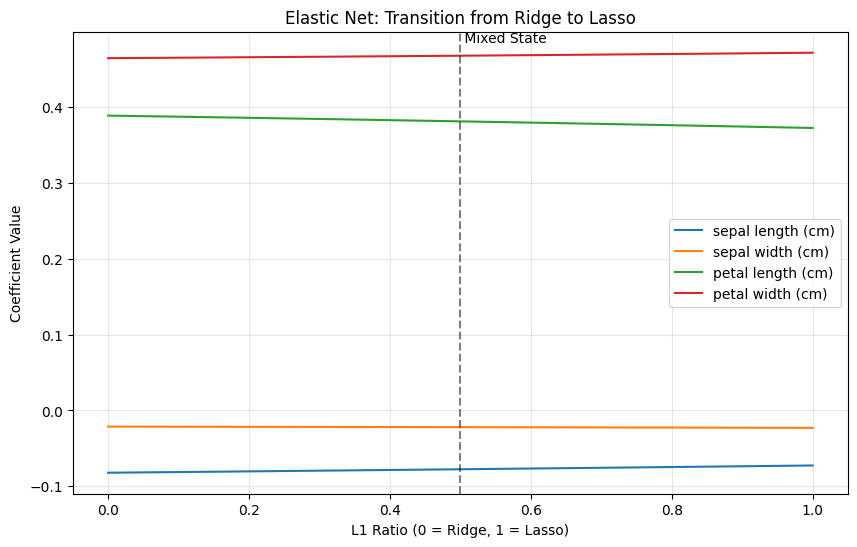

In [ ]:
import matplotlib.pyplot as plt

# We will test different L1 ratios from 0 (Ridge) to 1 (Lasso)
ratios = np.linspace(0, 1, 10)
coefs = []

for r in ratios:
    model = ElasticNetRegression(lr=0.1, n_iterations=1000, alpha=0.5, l1_ratio=r)
    model.fit(X_final, y)
    coefs.append(model.weights.flatten()[1:]) # Ignore intercept for plotting

# Plotting the weights
plt.figure(figsize=(10, 6))
plt.plot(ratios, coefs)
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
plt.text(0.5, plt.ylim()[1], ' Mixed State', verticalalignment='top')
plt.xlabel('L1 Ratio (0 = Ridge, 1 = Lasso)')
plt.ylabel('Coefficient Value')
plt.title('Elastic Net: Transition from Ridge to Lasso')
plt.legend(iris.feature_names, loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Visualization

*In our Elastic Net implementation, we successfully merged the strengths of Ridge and Lasso into a single, robust model. By adding both L1 (absolute value) and L2 (squared) penalties to our cost function, we gave the model a "mixing ratio" that balances feature elimination with weight stabilization. This hybrid approach is the ultimate solution for datasets where features are highly correlated; it prevents the erratic feature-dropping of Lasso while still providing the dimensionality reduction that pure Ridge lacks. In short, we built a tool that is smart enough to ignore noise but stable enough to keep essential, redundant information intact.*